In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf

2025-10-20 21:53:09.606588: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pandas as pd

df = pd.read_csv('emails.csv')
df.head()

,Spam,Message
0,0,Please call me at 8
1,1,Free money is available for you
2,0,I study he studies they are students I studied...
3,1,I am working at office now to 9 evening
4,0,U dun say so early hor... U c already then say...


In [3]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/abdulrahman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/abdulrahman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/abdulrahman/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
text = 'Hi: i am working on spam classification!'
tokens = word_tokenize(text.lower())
tokens

['hi', ':', 'i', 'am', 'working', 'on', 'spam', 'classification', '!']

In [5]:
import string
tokens = [token for token in tokens if token not in string.punctuation ]
tokens

['hi', 'i', 'am', 'working', 'on', 'spam', 'classification']

In [6]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [7]:
stop_words = stopwords.words('english')
tokens = [token for token in tokens if token not in stop_words ]
tokens

['hi', 'working', 'spam', 'classification']

In [8]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [9]:
print(len(stop_words))

198


In [10]:
stemmer = PorterStemmer()
tokens = [stemmer.stem(token) for token in tokens ]
tokens

['hi', 'work', 'spam', 'classif']

In [11]:
ps = PorterStemmer()
print(ps.stem('computer'))
print(ps.stem('computation'))
print(ps.stem('compute'))
print(ps.stem('computed'))
print(ps.stem('computers'))

comput
comput
comput
comput
comput


In [12]:
import re
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token not in string.punctuation ]
    
    stop_words = stopwords.words('english')
    tokens = [token for token in tokens if token not in stop_words ]
    
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens ]

    preprocessed_text = ' '.join(tokens)
    preprocessed_text = re.sub(r'http\S+|www\S+','',preprocessed_text)
    preprocessed_text = re.sub(r'\d+','',preprocessed_text)

    return preprocessed_text

In [13]:
email = 'Hello! these are 47584 examples for email spam classification. '
preprocessed_email = preprocess_text(email)
preprocessed_email

'hello  exampl email spam classif'

In [14]:
df['preprocessed_message'] = df['Message'].apply(preprocess_text)
df

,Spam,Message,preprocessed_message
0,0,Please call me at 8,pleas call
1,1,Free money is available for you,free money avail
2,0,I study he studies they are students I studied...,studi studi student studi yesterday
3,1,I am working at office now to 9 evening,work offic even
4,0,U dun say so early hor... U c already then say...,u dun say earli hor ... u c alreadi say ...
...,...,...,...
5222,0,"It‘s reassuring, in this crazy world.",‘ reassur crazi world
5223,0,Oh... Okie lor...We go on sat...,oh ... oki lor ... go sat ...
5224,1,You are awarded a SiPix Digital Camera! call 0...,award sipix digit camera call landlin deliver...
5225,0,"Hey chief, can you give me a bell when you get...",hey chief give bell get need talk royal visit ...


In [15]:
df_spam = df[df['Spam']==1]
df_spam

,Spam,Message,preprocessed_message
1,1,Free money is available for you,free money avail
3,1,I am working at office now to 9 evening,work offic even
6,1,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl 's week 's word back 'd like...
9,1,WINNER!! As a valued network customer you have...,winner valu network custom select receivea آ£ ...
10,1,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mo...
...,...,...,...
5217,1,URGENT! Last weekend's draw shows that you hav...,urgent last weekend 's draw show £ cash spanis...
5219,1,URGENT We are trying to contact you Last weeke...,urgent tri contact last weekend draw show u £ ...
5221,1,Marvel Mobile Play the official Ultimate Spide...,marvel mobil play offici ultim spider-man game...
5224,1,You are awarded a SiPix Digital Camera! call 0...,award sipix digit camera call landlin deliver...


In [16]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


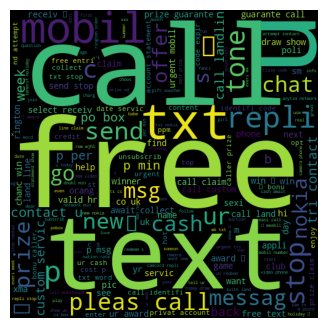

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
spam_words_list = df_spam['preprocessed_message'].astype(str)
spam_words_str = ' '.join(spam_words_list)
spam_wordcloud = WordCloud(height=500,width=500).generate(spam_words_str)
plt.figure(figsize=(6,4))
plt.imshow(spam_wordcloud)
plt.axis('off')
plt.show()

In [18]:
from sklearn.feature_extraction.text import CountVectorizer 

documents = [
    "My cat and dog sat on the mat",
    "strange cat jumped over the mat",
    "His cat ate the mouse ran across the mat",
    "Her dog run after my cat and mouse",
]

max_features=6

count_vectorizer = CountVectorizer(max_features=max_features)

vectors = count_vectorizer.fit_transform(documents)

print(vectors)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (4, 6)>
  Coords	Values
  (0, 4)	1
  (0, 0)	1
  (0, 1)	1
  (0, 5)	1
  (0, 2)	1
  (1, 0)	1
  (1, 5)	1
  (1, 2)	1
  (2, 0)	1
  (2, 5)	2
  (2, 2)	1
  (2, 3)	1
  (3, 4)	1
  (3, 0)	1
  (3, 1)	1
  (3, 3)	1


In [19]:
feature_names = count_vectorizer.get_feature_names_out()
feature_names

array(['cat', 'dog', 'mat', 'mouse', 'my', 'the'], dtype=object)

In [20]:
vectors.toarray()

array([[1, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 0, 1],
       [1, 0, 1, 1, 0, 2],
       [1, 1, 0, 1, 1, 0]])

In [21]:
example_df = pd.DataFrame(data=vectors.toarray(),columns=feature_names)
example_df

,cat,dog,mat,mouse,my,the
0,1,1,1,0,1,1
1,1,0,1,0,0,1
2,1,0,1,1,0,2
3,1,1,0,1,1,0


In [22]:
frequicies = vectors.toarray().sum(axis=0)
frequicies

array([4, 2, 3, 2, 2, 4])

In [23]:
sorted_indices = frequicies.argsort()[::-1]
sorted_indices

array([5, 0, 2, 4, 3, 1])

In [24]:
sorted_feature_names = [feature_names[idx] for idx in sorted_indices]
sorted_feature_names

['the', 'cat', 'mat', 'my', 'mouse', 'dog']

In [25]:
sorted_frequicies= frequicies[sorted_indices]
sorted_frequicies

array([4, 4, 3, 2, 2, 2])

In [26]:
for i in range(len(sorted_feature_names)):
    print(sorted_feature_names[i],";",sorted_frequicies[i])

the ; 4
cat ; 4
mat ; 3
my ; 2
mouse ; 2
dog ; 2


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
tfidf_vectors = tfidf_vectorizer.fit_transform(documents)
print("\nTF-IDF Vectorization:")

feature_names=tfidf_vectorizer.get_feature_names_out()

example_df = pd.DataFrame(data=tfidf_vectors.toarray(),columns=feature_names)
example_df


TF-IDF Vectorization:


,cat,dog,mat,mouse,my,the
0,0.341846,0.516470,0.418127,0.000000,0.516470,0.418127
1,0.500491,0.000000,0.612172,0.000000,0.000000,0.612172
2,0.304813,0.000000,0.372830,0.460519,0.000000,0.745660
3,0.356966,0.539313,0.000000,0.539313,0.539313,0.000000


In [28]:
corpus = df['preprocessed_message']


max_features = 100

count_vectorizer = CountVectorizer(max_features=max_features)

vectors = count_vectorizer.fit_transform(corpus)

tfidf_vectorizer = TfidfVectorizer(max_features=max_features)
tfidf_vectors = tfidf_vectorizer.fit_transform(corpus)

In [29]:
from sklearn.model_selection import train_test_split

X = vectors

y = df['Spam']

X = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [30]:
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=30, batch_size=32)

Epoch 1/30


/home/abdulrahman/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-20 21:53:26.138149: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-10-20 21:53:26.138174: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2025-10-20 21:53:26.138180: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-10-20 21:53:26.138186: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun wit

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.3846 
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9495 - loss: 0.1524 
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9571 - loss: 0.1216 
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9599 - loss: 0.1110 
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9651 - loss: 0.1043 
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9668 - loss: 0.0977 
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.0922 
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9712 - loss: 0.0880 
Epoch 9/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9755 - loss: 0.0813 
Epoch 10/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9778 - loss: 0.0765 
Epoch 11/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9768 - loss: 0.0721 
Epoch 12/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [31]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.round(y_pred_prob)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 97.17


In [32]:
from sklearn.model_selection import train_test_split

X = tfidf_vectors

y = df['Spam']

X = X.toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [33]:
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=30, batch_size=32)

Epoch 1/30


/home/abdulrahman/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.3987    
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9291 - loss: 0.1895 
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9541 - loss: 0.1358 
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9589 - loss: 0.1228 
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9602 - loss: 0.1143 
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9620 - loss: 0.1087 
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9671 - loss: 0.1024 
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9681 - loss: 0.0970 
Epoch 9/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9691 - loss: 0.0908 
Epoch 10/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9724 - loss: 0.0864 
Epoch 11/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9747 - loss: 0.0815 
Epoch 12/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [34]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.round(y_pred_prob)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 97.09


In [35]:
message="call to get free prize one million dollars"

processed_message=preprocess_text(message)

vector=tfidf_vectorizer.transform([processed_message])
vector_dense=vector.toarray()

y_pred_prob = model.predict(vector_dense)

y_pred = np.round(y_pred_prob)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[1.]]
